In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

DATA_FILE = "ec2_request_latency_system_failure.csv"
LABEL_FILE = "combined_windows.json"
LABEL_KEY = "realKnownCause/ec2_request_latency_system_failure.csv"

In [13]:
def load_data():
    return pd.read_csv(DATA_FILE, parse_dates=["timestamp"])


def load_windows():
    with open(LABEL_FILE) as f:
        windows = json.load(f)[LABEL_KEY]
    return [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in windows]

In [14]:
df = load_data()
windows = load_windows()
print(df.shape)
print(df.head())
print(windows)

(4032, 2)
            timestamp   value
0 2014-03-07 03:41:00  45.868
1 2014-03-07 03:46:00  47.606
2 2014-03-07 03:51:00  42.580
3 2014-03-07 03:56:00  46.030
4 2014-03-07 04:01:00  44.992
[(Timestamp('2014-03-14 03:31:00'), Timestamp('2014-03-14 14:41:00')), (Timestamp('2014-03-18 17:06:00'), Timestamp('2014-03-19 04:16:00')), (Timestamp('2014-03-20 21:26:00'), Timestamp('2014-03-21 03:41:00'))]


In [15]:
def rolling_zscore_flags(df, window=48, threshold=2.0):
    mean = df["value"].rolling(window).mean()
    std = df["value"].rolling(window).std()
    z = (df["value"] - mean) / std
    return z.abs() > threshold


def isolation_forest_flags(df, contamination=0.03):
    X = pd.DataFrame({
        "value": df["value"],
        "diff": df["value"].diff().fillna(0),
        "roll_mean": df["value"].rolling(12, min_periods=1).mean(),
    })
    model = IsolationForest(contamination=contamination, random_state=42)
    return pd.Series(model.fit_predict(X) == -1, index=df.index)


def to_events(df, flags):
    events, start, prev = [], None, None
    for ts, flag in zip(df["timestamp"], flags):
        if flag and start is None:
            start = ts
        if not flag and start is not None:
            events.append((start, prev))
            start = None
        prev = ts
    if start is not None:
        events.append((start, prev))
    return events

In [16]:
def evaluate(events, windows):
    caught = sum(any(s <= w_end and e >= w_start for s, e in events)
                 for w_start, w_end in windows)
    false_alarms = sum(not any(s <= w_end and e >= w_start for w_start, w_end in windows)
                       for s, e in events)
    return caught, len(windows), false_alarms, len(events)


def summarize(df, events, limit=5):
    typical = df["value"].median()
    for s, e in events[:limit]:
        part = df[(df["timestamp"] >= s) & (df["timestamp"] <= e)]
        print(f"- {s:%Y-%m-%d %H:%M} to {e:%Y-%m-%d %H:%M}: "
              f"peak {part['value'].max():.1f} vs typical {typical:.1f}")

In [17]:
def plot(df, windows, flags_a, flags_b):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    panels = [(axes[0], flags_a, "Rolling z-score (baseline)"),
              (axes[1], flags_b, "Isolation Forest")]
    for ax, flags, title in panels:
        ax.plot(df["timestamp"], df["value"], linewidth=0.8)
        for s, e in windows:
            ax.axvspan(s, e, alpha=0.25, color="red")
        ax.scatter(df.loc[flags, "timestamp"], df.loc[flags, "value"],
                   s=12, color="orange")
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig("result.png", dpi=150)
    plt.show()

Rolling z-score: caught 3/3 real incident windows, 143 false alarms out of 154 alerts
Isolation Forest: caught 3/3 real incident windows, 63 false alarms out of 73 alerts

Isolation Forest alerts (first 5):
- 2014-03-07 08:16 to 2014-03-07 08:16: peak 40.6 vs typical 45.0
- 2014-03-07 10:41 to 2014-03-07 10:41: peak 41.0 vs typical 45.0
- 2014-03-07 15:46 to 2014-03-07 15:46: peak 40.9 vs typical 45.0
- 2014-03-08 07:51 to 2014-03-08 07:51: peak 39.7 vs typical 45.0
- 2014-03-08 10:51 to 2014-03-08 10:51: peak 40.3 vs typical 45.0


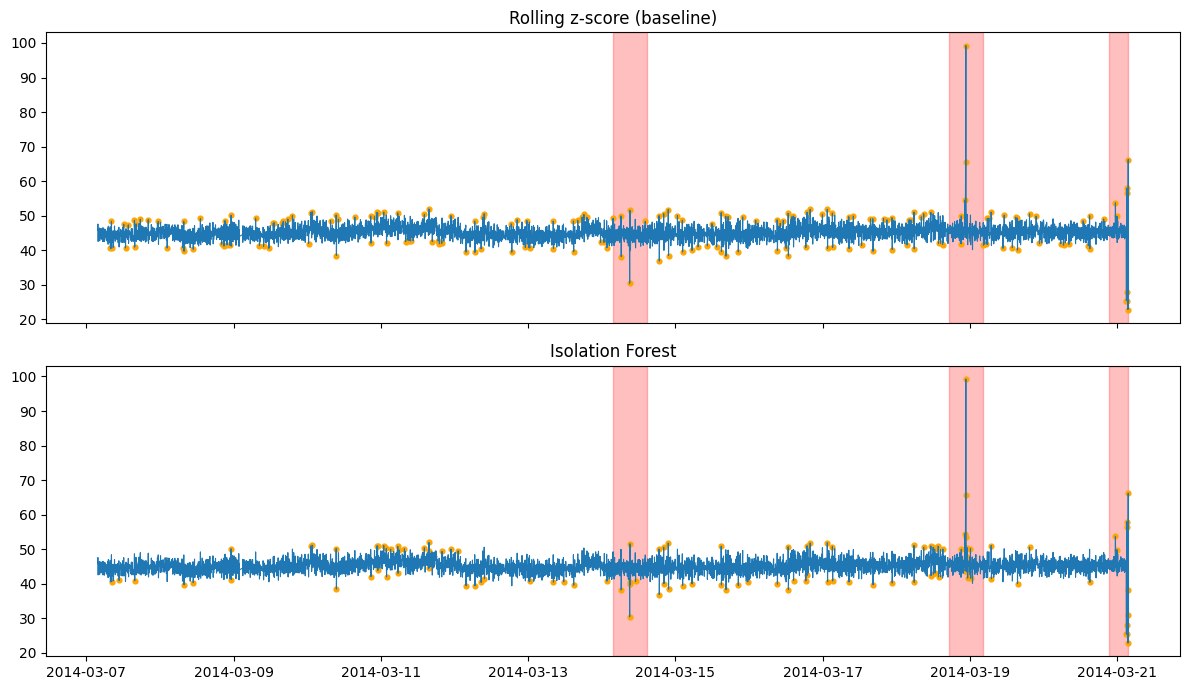

In [18]:
flags_z = rolling_zscore_flags(df)
flags_if = isolation_forest_flags(df)

for name, flags in [("Rolling z-score", flags_z), ("Isolation Forest", flags_if)]:
    events = to_events(df, flags)
    caught, total, fa, n = evaluate(events, windows)
    print(f"{name}: caught {caught}/{total} real incident windows, "
          f"{fa} false alarms out of {n} alerts")

print("\nIsolation Forest alerts (first 5):")
summarize(df, to_events(df, flags_if))
plot(df, windows, flags_z, flags_if)